In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

In [2]:
# Load California Housing Dataset
housing = fetch_california_housing()

# Store features and target in NumPy arrays
X = np.array(housing.data, dtype=np.float64)
y = np.array(housing.target, dtype=np.float64)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (20640, 8)
Target vector shape: (20640,)


In [3]:
# Fixed random seed as specified in the assignment
np.random.seed(9432)

# Number of samples
n_samples = X.shape[0]

# Generate shuffled indices
indices = np.arange(n_samples)
np.random.shuffle(indices)

# Shuffle features and targets using the same indices
X_shuffled = X[indices]
y_shuffled = y[indices]

# Calculate split sizes
train_size = int(0.60 * n_samples)
val_size = int(0.20 * n_samples)

# Split the data
X_train = X_shuffled[:train_size]
y_train = y_shuffled[:train_size]

X_val = X_shuffled[train_size:train_size + val_size]
y_val = y_shuffled[train_size:train_size + val_size]

X_test = X_shuffled[train_size + val_size:]
y_test = y_shuffled[train_size + val_size:]

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (12384, 8) (12384,)
Validation set: (4128, 8) (4128,)
Test set: (4128, 8) (4128,)


In [4]:
# Calculate normalization parameters ONLY from training data
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

# Normalize all three datasets using training parameters
X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

print("Training feature means:")
print(np.mean(X_train_norm, axis=0))

print("\nTraining feature standard deviations:")
print(np.std(X_train_norm, axis=0))

Training feature means:
[ 6.67028520e-15 -4.05687721e-17 -1.97551946e-15 -9.56487359e-15
 -1.04742335e-16  1.83242942e-15  2.76463194e-14 -1.64395485e-13]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [5]:
# Add a column of ones for the bias term

X_train_aug = np.hstack(
    (X_train_norm, np.ones((X_train_norm.shape[0], 1)))
)

X_val_aug = np.hstack(
    (X_val_norm, np.ones((X_val_norm.shape[0], 1)))
)

X_test_aug = np.hstack(
    (X_test_norm, np.ones((X_test_norm.shape[0], 1)))
)

print("Augmented training shape:", X_train_aug.shape)
print("Augmented validation shape:", X_val_aug.shape)
print("Augmented test shape:", X_test_aug.shape)

Augmented training shape: (12384, 9)
Augmented validation shape: (4128, 9)
Augmented test shape: (4128, 9)


In [6]:
# Target normalization parameters from training data only
y_mean = np.mean(y_train)
y_std = np.std(y_train)

# Standardize target values
y_train_std = (y_train - y_mean) / y_std
y_val_std = (y_val - y_mean) / y_std
y_test_std = (y_test - y_mean) / y_std

print("Training target mean:", np.mean(y_train_std))
print("Training target std:", np.std(y_train_std))

Training target mean: 9.753897373967783e-17
Training target std: 1.0


In [7]:
def mse_loss(y_true, y_pred):
    """
    Calculate Mean Squared Error.
    """
    return np.mean((y_true - y_pred) ** 2)


def compute_gradient(X_batch, y_batch, weights):
    """
    Calculate gradient of MSE with respect to weights.
    
    Gradient:
        (2/m) * X^T(XW - y)
    """
    m = X_batch.shape[0]

    predictions = X_batch @ weights
    error = predictions - y_batch

    gradient = (2 / m) * (X_batch.T @ error)

    return gradient


def mini_batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate,
    batch_size,
    max_epochs=1000,
    patience=100,
    random_seed=9432
):
    """
    Train Linear Regression using Mini-Batch Gradient Descent.
    
    Returns:
        best_weights
        training_losses
        validation_losses
        best_epoch
    """

    # Number of features including bias
    n_features = X_train.shape[1]

    # Initialize weights with zero vector
    weights = np.zeros(n_features)

    # Store losses
    training_losses = []
    validation_losses = []

    # Best-model information
    best_weights = weights.copy()
    best_val_loss = np.inf
    best_epoch = 0

    # Early stopping counter
    epochs_without_improvement = 0

    # Set seed for reproducible mini-batch shuffling
    np.random.seed(random_seed)

    for epoch in range(1, max_epochs + 1):

        # --------------------------------------------
        # Step 1: Shuffle training data
        # --------------------------------------------
        indices = np.random.permutation(X_train.shape[0])

        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        # --------------------------------------------
        # Step 2: Mini-batch training
        # --------------------------------------------
        weighted_loss_sum = 0.0
        total_samples = 0

        for start in range(0, X_train.shape[0], batch_size):

            end = min(start + batch_size, X_train.shape[0])

            X_batch = X_train_shuffled[start:end]
            y_batch = y_train_shuffled[start:end]

            batch_count = X_batch.shape[0]

            # Prediction
            predictions = X_batch @ weights

            # Calculate batch loss
            batch_loss = mse_loss(y_batch, predictions)

            # Accumulate sample-weighted loss
            weighted_loss_sum += batch_loss * batch_count
            total_samples += batch_count

            # Calculate gradient
            gradient = compute_gradient(
                X_batch,
                y_batch,
                weights
            )

            # Update weights
            weights -= learning_rate * gradient

        # --------------------------------------------
        # Step 3: Epoch training MSE
        # --------------------------------------------
        epoch_train_loss = weighted_loss_sum / total_samples

        # --------------------------------------------
        # Step 4: Validation MSE
        # --------------------------------------------
        val_predictions = X_val @ weights

        epoch_val_loss = mse_loss(
            y_val,
            val_predictions
        )

        # Store losses
        training_losses.append(epoch_train_loss)
        validation_losses.append(epoch_val_loss)

        # --------------------------------------------
        # Step 5: Check validation improvement
        # --------------------------------------------
        if epoch_val_loss < best_val_loss:

            best_val_loss = epoch_val_loss

            # Save a copy of the best weights
            best_weights = weights.copy()

            best_epoch = epoch

            # Reset patience
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        # --------------------------------------------
        # Step 6: Early stopping
        # --------------------------------------------
        if epochs_without_improvement >= patience:
            break

    return (
        best_weights,
        np.array(training_losses),
        np.array(validation_losses),
        best_epoch
    )

In [8]:
def predict(X, weights):
    """
    Generate predictions using matrix multiplication.
    """
    return X @ weights

In [9]:
def inverse_transform_target(y_standardized):
    """
    Convert standardized target back to original scale.
    """
    return y_standardized * y_std + y_mean

In [10]:
learning_rates = [
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
    10
]

batch_size = 128

learning_rate_results = {}

for lr in learning_rates:

    print(f"Training with learning rate = {lr}")

    (
        best_weights,
        train_losses,
        val_losses,
        best_epoch
    ) = mini_batch_gradient_descent(
        X_train_aug,
        y_train_std,
        X_val_aug,
        y_val_std,
        learning_rate=lr,
        batch_size=batch_size,
        max_epochs=1000,
        patience=100,
        random_seed=9432
    )

    learning_rate_results[lr] = {
        "weights": best_weights,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_epoch": best_epoch,
        "best_val_mse": np.min(val_losses)
    }

    print(
        f"Best validation MSE = "
        f"{np.min(val_losses):.6f}, "
        f"Best epoch = {best_epoch}"
    )

Training with learning rate = 1e-05
Best validation MSE = 0.471494, Best epoch = 1000
Training with learning rate = 0.0001
Best validation MSE = 0.396840, Best epoch = 1000
Training with learning rate = 0.001
Best validation MSE = 0.391665, Best epoch = 295
Training with learning rate = 0.01
Best validation MSE = 0.390593, Best epoch = 27
Training with learning rate = 0.1


C:\Users\TASVI\AppData\Local\Temp\ipykernel_8404\3002301887.py:5: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
c:\Users\TASVI\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\TASVI\AppData\Local\Temp\ipykernel_8404\3002301887.py:20: RuntimeWarning: overflow encountered in matmul
  gradient = (2 / m) * (X_batch.T @ error)
C:\Users\TASVI\AppData\Local\Temp\ipykernel_8404\3002301887.py:93: RuntimeWarning: invalid value encountered in matmul
  predictions = X_batch @ weights
C:\Users\TASVI\AppData\Local\Temp\ipykernel_8404\3002301887.py:17: RuntimeWarning: invalid value encountered in matmul
  predictions = X_batch @ weights
C:\Users\TASVI\AppData\Local\Temp\ipykernel_8404\3002301887.py:20: RuntimeWarning: invalid value encountered in matmul
  gradient = (2 / m) * (X_batch.T @ error)


Best validation MSE = 646.154718, Best epoch = 1
Training with learning rate = 1
Best validation MSE = nan, Best epoch = 1
Training with learning rate = 10
Best validation MSE = nan, Best epoch = 0


In [11]:
best_learning_rate = min(
    learning_rate_results,
    key=lambda lr: learning_rate_results[lr]["best_val_mse"]
)

print("Best Learning Rate:", best_learning_rate)
print(
    "Best Validation MSE:",
    learning_rate_results[best_learning_rate]["best_val_mse"]
)

Best Learning Rate: 0.01
Best Validation MSE: 0.39059292502938336


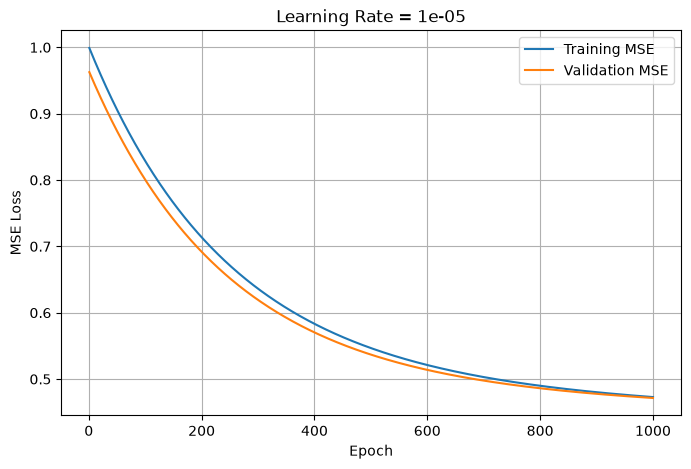

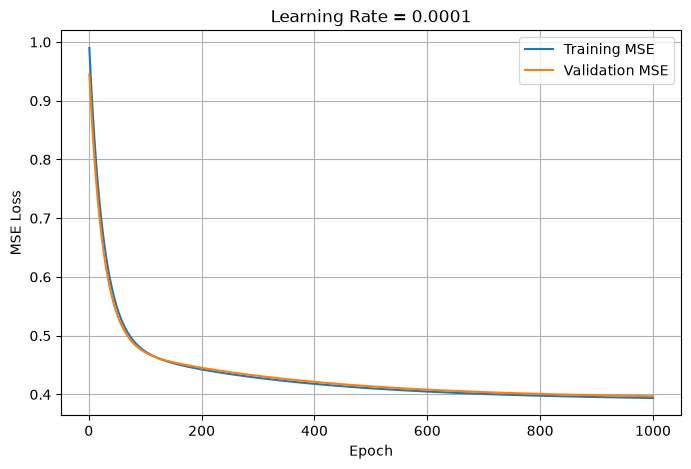

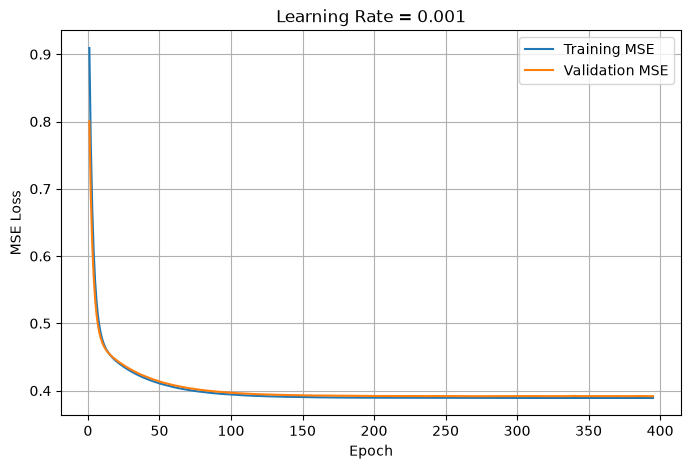

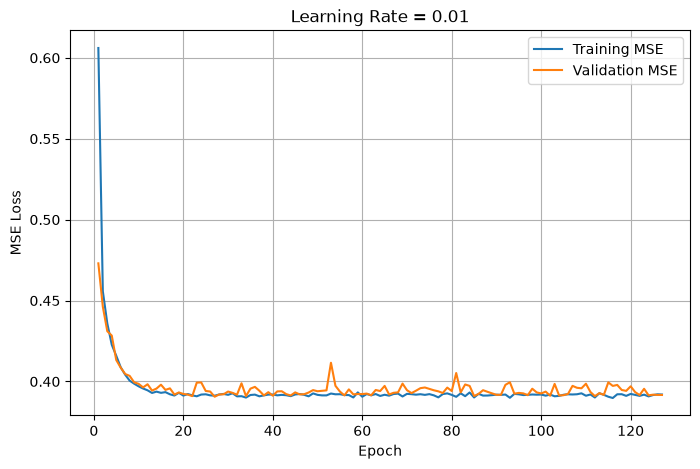

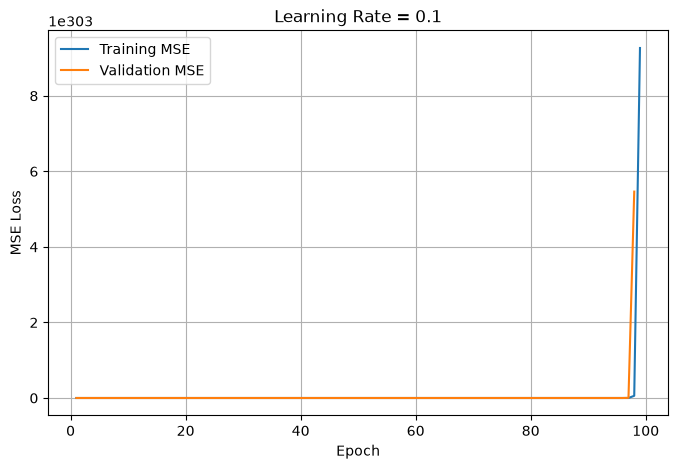

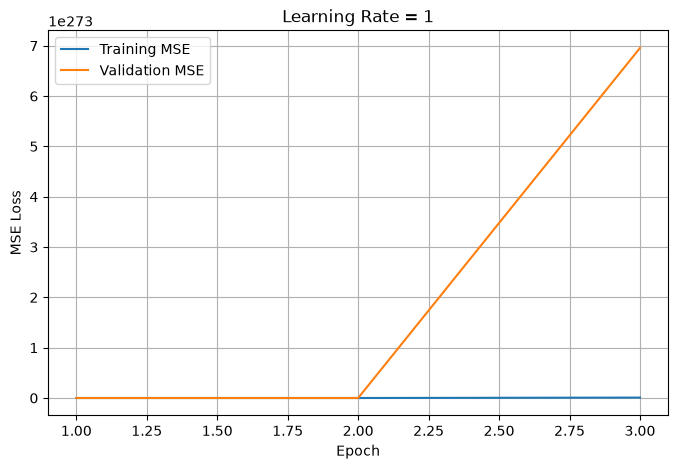

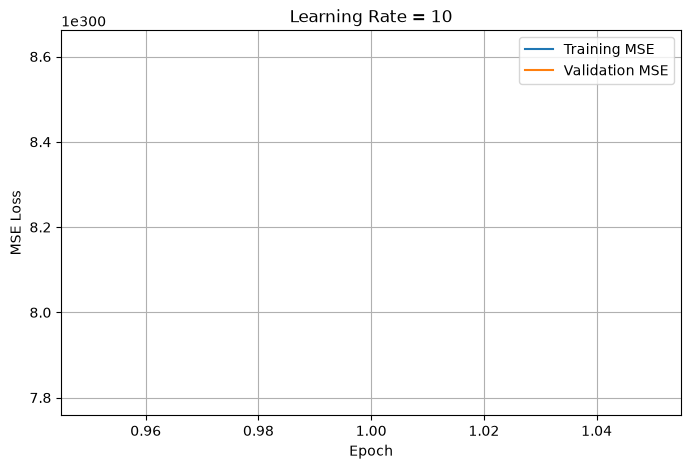

In [12]:
for lr in learning_rates:

    result = learning_rate_results[lr]

    train_losses = result["train_losses"]
    val_losses = result["val_losses"]

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_losses,
        label="Training MSE"
    )

    plt.plot(
        epochs,
        val_losses,
        label="Validation MSE"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Learning Rate = {lr}")
    plt.legend()
    plt.grid(True)

    plt.show()

In [13]:
best_lr = best_learning_rate

batch_sizes = [
    1,
    16,
    32,
    64,
    128,
    256,
    X_train_aug.shape[0]
]

batch_size_results = {}

for bs in batch_sizes:

    print(f"\nTraining with batch size = {bs}")

    (
        best_weights,
        train_losses,
        val_losses,
        best_epoch
    ) = mini_batch_gradient_descent(
        X_train_aug,
        y_train_std,
        X_val_aug,
        y_val_std,
        learning_rate=best_lr,
        batch_size=bs,
        max_epochs=1000,
        patience=100,
        random_seed=9432
    )

    batch_size_results[bs] = {
        "weights": best_weights,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_epoch": best_epoch,
        "best_val_mse": np.min(val_losses)
    }

    print(
        f"Best Validation MSE = "
        f"{np.min(val_losses):.6f}"
    )

    print(
        f"Best Epoch = {best_epoch}"
    )


Training with batch size = 1


C:\Users\TASVI\AppData\Local\Temp\ipykernel_8404\3002301887.py:99: RuntimeWarning: overflow encountered in scalar add
  weighted_loss_sum += batch_loss * batch_count
C:\Users\TASVI\AppData\Local\Temp\ipykernel_8404\3002301887.py:5: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)


Best Validation MSE = 1831.183491
Best Epoch = 1

Training with batch size = 16
Best Validation MSE = 152.640760
Best Epoch = 1

Training with batch size = 32
Best Validation MSE = 1.006871
Best Epoch = 1

Training with batch size = 64
Best Validation MSE = 0.390257
Best Epoch = 28

Training with batch size = 128
Best Validation MSE = 0.390593
Best Epoch = 27

Training with batch size = 256
Best Validation MSE = 0.391202
Best Epoch = 151

Training with batch size = 12384
Best Validation MSE = 0.396396
Best Epoch = 1000


In [14]:
print(
    f"{'Batch Size':<20}"
    f"{'Lowest Validation MSE':<25}"
    f"{'Best Epoch':<15}"
)

print("-" * 60)

for bs in batch_sizes:

    result = batch_size_results[bs]

    print(
        f"{str(bs):<20}"
        f"{result['best_val_mse']:<25.6f}"
        f"{result['best_epoch']:<15}"
    )

Batch Size          Lowest Validation MSE    Best Epoch     
------------------------------------------------------------
1                   1831.183491              1              
16                  152.640760               1              
32                  1.006871                 1              
64                  0.390257                 28             
128                 0.390593                 27             
256                 0.391202                 151            
12384               0.396396                 1000           


In [15]:
print("Batch Size\tLowest Validation MSE\tBest Epoch")

for bs in batch_sizes:

    result = batch_size_results[bs]

    print(
        f"{bs}\t\t"
        f"{result['best_val_mse']:.6f}\t\t\t"
        f"{result['best_epoch']}"
    )

Batch Size	Lowest Validation MSE	Best Epoch
1		1831.183491			1
16		152.640760			1
32		1.006871			1
64		0.390257			28
128		0.390593			27
256		0.391202			151
12384		0.396396			1000


In [16]:
best_batch_size = min(
    batch_size_results,
    key=lambda bs: batch_size_results[bs]["best_val_mse"]
)

print("Best Batch Size:", best_batch_size)

print(
    "Lowest Validation MSE:",
    batch_size_results[best_batch_size]["best_val_mse"]
)

print(
    "Best Epoch:",
    batch_size_results[best_batch_size]["best_epoch"]
)

Best Batch Size: 64
Lowest Validation MSE: 0.3902567621180774
Best Epoch: 28


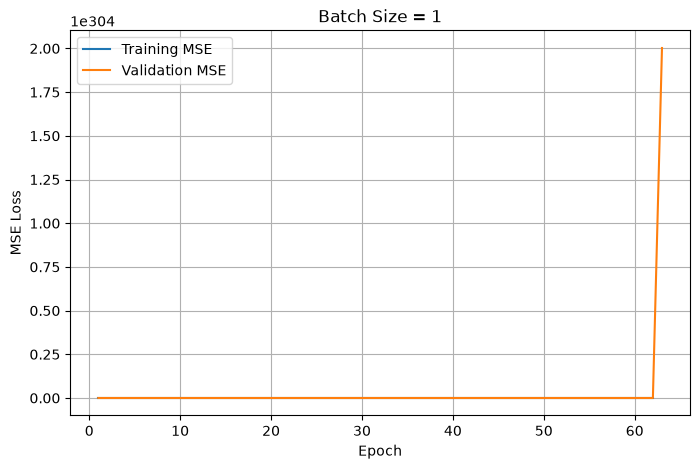

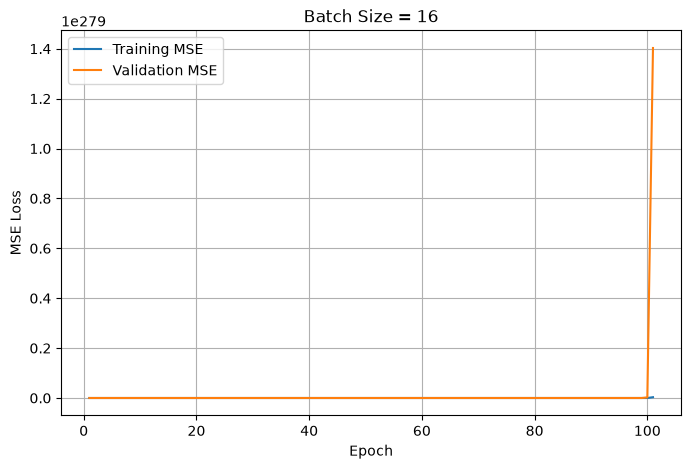

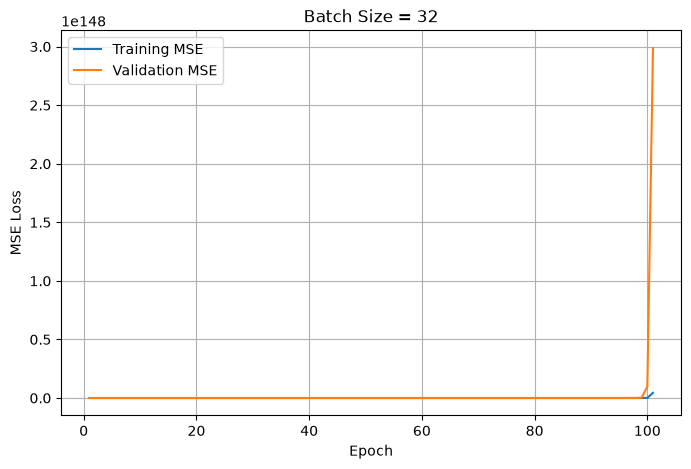

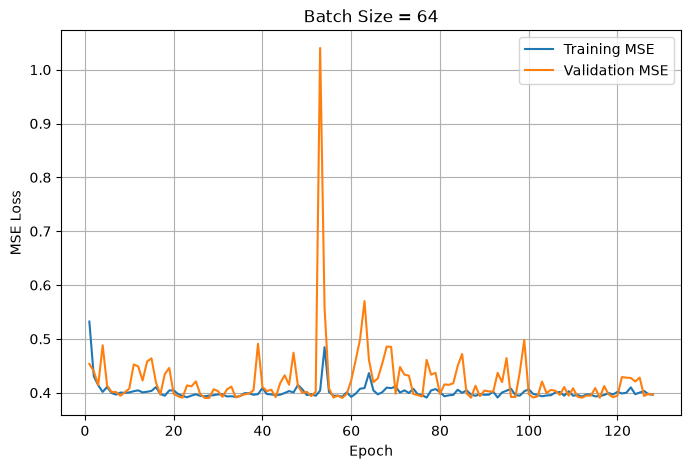

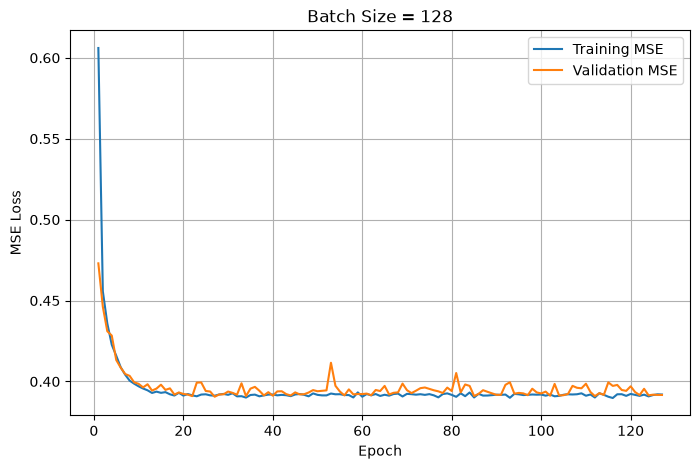

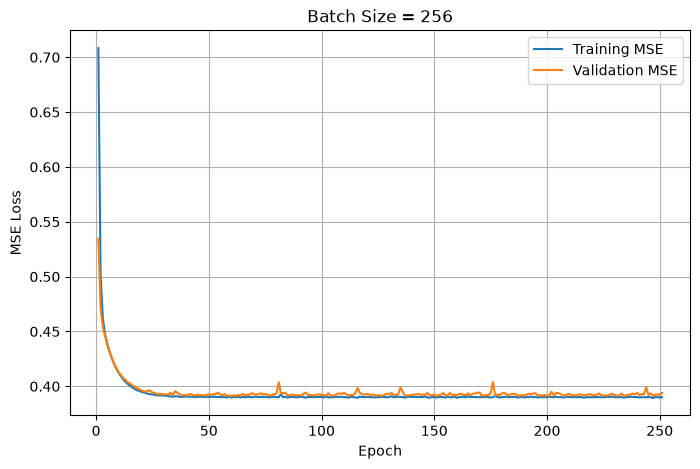

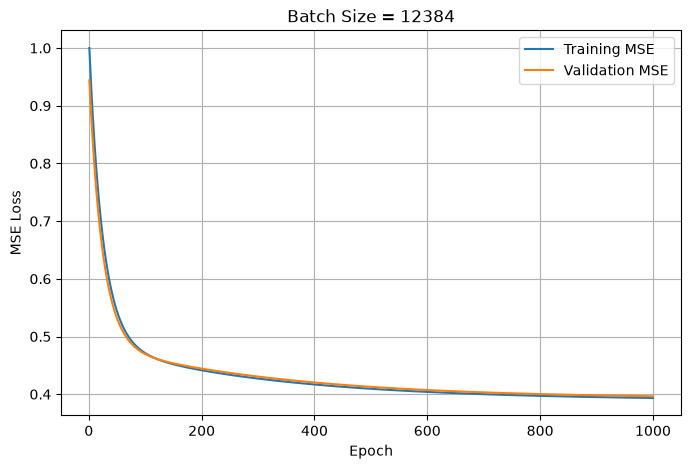

In [17]:
for bs in batch_sizes:

    result = batch_size_results[bs]

    train_losses = result["train_losses"]
    val_losses = result["val_losses"]

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_losses,
        label="Training MSE"
    )

    plt.plot(
        epochs,
        val_losses,
        label="Validation MSE"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Batch Size = {bs}")
    plt.legend()
    plt.grid(True)

    plt.show()

In [18]:
best_lr = best_learning_rate
best_bs = best_batch_size

print("Final Learning Rate:", best_lr)
print("Final Batch Size:", best_bs)

Final Learning Rate: 0.01
Final Batch Size: 64


In [19]:
final_weights = batch_size_results[best_bs]["weights"]

final_best_epoch = batch_size_results[best_bs]["best_epoch"]

print("Final best epoch:", final_best_epoch)

Final best epoch: 28


In [20]:
# Predictions in standardized target scale

train_pred_std = predict(
    X_train_aug,
    final_weights
)

val_pred_std = predict(
    X_val_aug,
    final_weights
)

test_pred_std = predict(
    X_test_aug,
    final_weights
)

In [21]:
# Convert predictions back to original target scale

train_pred = inverse_transform_target(train_pred_std)
val_pred = inverse_transform_target(val_pred_std)
test_pred = inverse_transform_target(test_pred_std)

In [22]:
def rmse(y_true, y_pred):
    return np.sqrt(
        np.mean((y_true - y_pred) ** 2)
    )

In [23]:
def mae(y_true, y_pred):
    return np.mean(
        np.abs(y_true - y_pred)
    )

In [24]:
def mape(y_true, y_pred):
    return np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

In [25]:
def r_squared(y_true, y_pred):

    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    return 1 - (ss_res / ss_tot)

In [26]:
train_rmse = rmse(y_train, train_pred)
train_mape = mape(y_train, train_pred)
train_mae = mae(y_train, train_pred)
train_r2 = r_squared(y_train, train_pred)

val_rmse = rmse(y_val, val_pred)
val_mape = mape(y_val, val_pred)
val_mae = mae(y_val, val_pred)
val_r2 = r_squared(y_val, val_pred)

test_rmse = rmse(y_test, test_pred)
test_mape = mape(y_test, test_pred)
test_mae = mae(y_test, test_pred)
test_r2 = r_squared(y_test, test_pred)

In [27]:
print(
    f"{'Dataset':<15}"
    f"{'RMSE':<15}"
    f"{'MAPE (%)':<15}"
    f"{'MAE':<15}"
    f"{'R-squared':<15}"
)

print("-" * 75)

print(
    f"{'Training':<15}"
    f"{train_rmse:<15.6f}"
    f"{train_mape:<15.6f}"
    f"{train_mae:<15.6f}"
    f"{train_r2:<15.6f}"
)

print(
    f"{'Validation':<15}"
    f"{val_rmse:<15.6f}"
    f"{val_mape:<15.6f}"
    f"{val_mae:<15.6f}"
    f"{val_r2:<15.6f}"
)

print(
    f"{'Test':<15}"
    f"{test_rmse:<15.6f}"
    f"{test_mape:<15.6f}"
    f"{test_mae:<15.6f}"
    f"{test_r2:<15.6f}"
)

Dataset        RMSE           MAPE (%)       MAE            R-squared      
---------------------------------------------------------------------------
Training       0.723081       31.526735      0.527556       0.609702       
Validation     0.723043       31.369138      0.532311       0.595357       
Test           0.730173       31.227239      0.531213       0.603821       


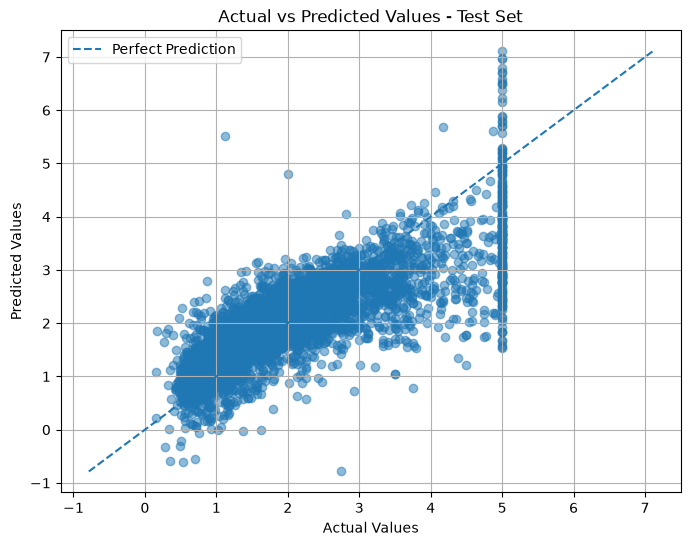

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.5
)

# Perfect prediction line
minimum = min(y_test.min(), test_pred.min())
maximum = max(y_test.max(), test_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values - Test Set")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
final_results = np.array([
    [train_rmse, train_mape, train_mae, train_r2],
    [val_rmse, val_mape, val_mae, val_r2],
    [test_rmse, test_mape, test_mae, test_r2]
])

print("Final Performance Metrics")
print()

print(
    f"{'Dataset':<15}"
    f"{'RMSE':<12}"
    f"{'MAPE (%)':<12}"
    f"{'MAE':<12}"
    f"{'R²':<12}"
)

print("-" * 63)

dataset_names = [
    "Training",
    "Validation",
    "Test"
]

for name, row in zip(dataset_names, final_results):

    print(
        f"{name:<15}"
        f"{row[0]:<12.6f}"
        f"{row[1]:<12.6f}"
        f"{row[2]:<12.6f}"
        f"{row[3]:<12.6f}"
    )

Final Performance Metrics

Dataset        RMSE        MAPE (%)    MAE         R²          
---------------------------------------------------------------
Training       0.723081    31.526735   0.527556    0.609702    
Validation     0.723043    31.369138   0.532311    0.595357    
Test           0.730173    31.227239   0.531213    0.603821    
